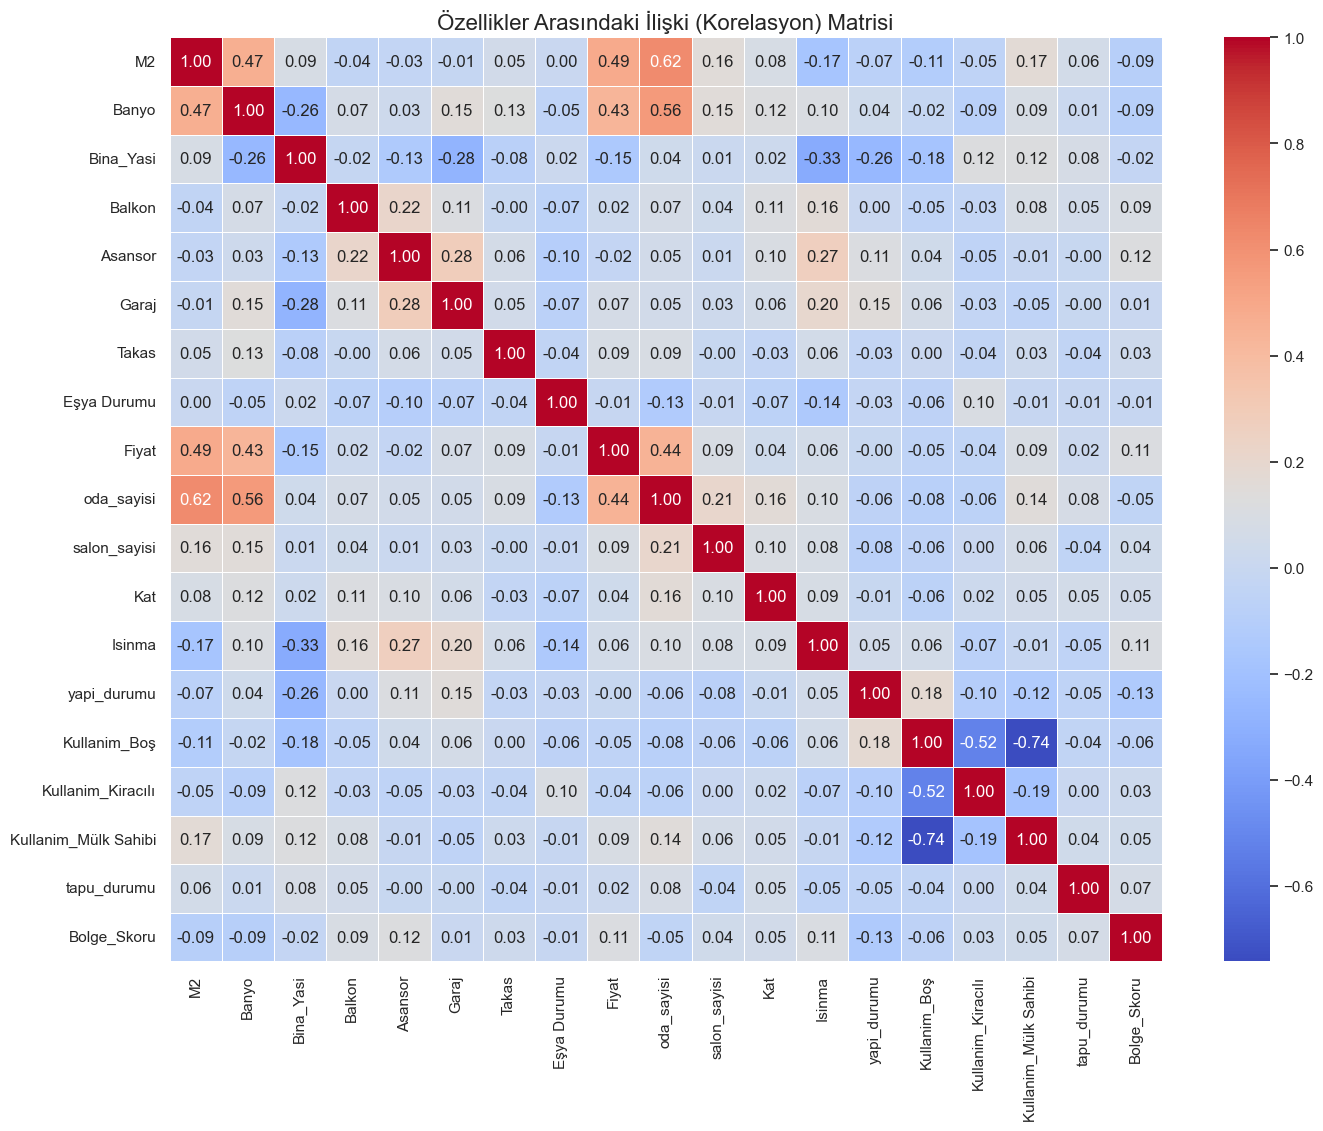

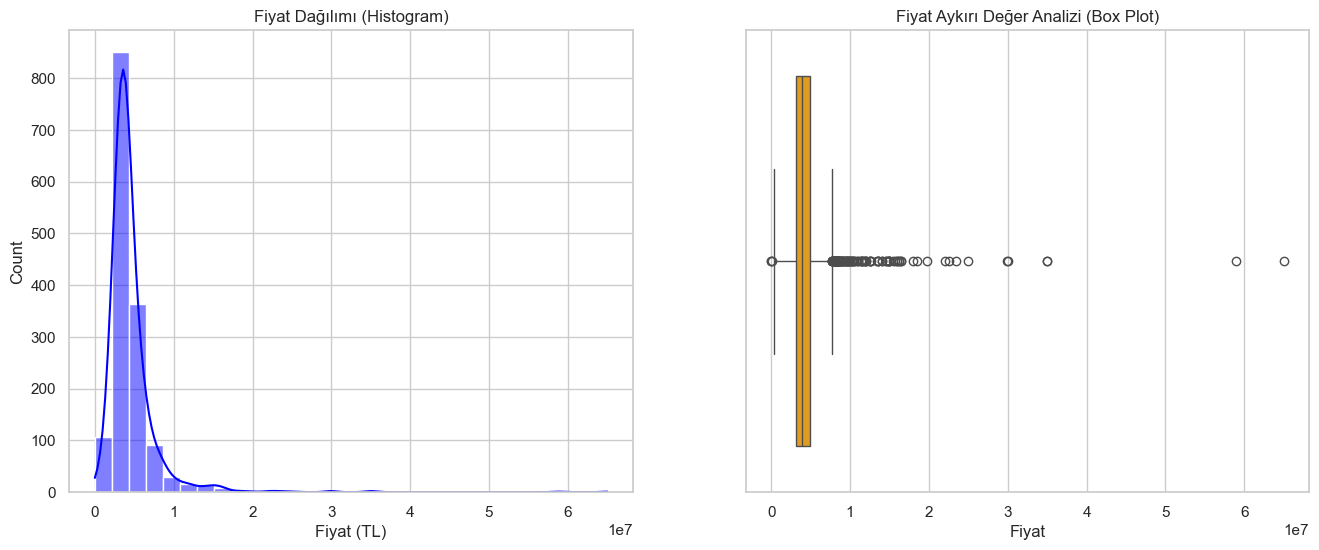

C:\Users\ASUS\AppData\Local\Temp\ipykernel_28216\811870314.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Bolge_Skoru', y='Fiyat', palette='Set2', ax=ax[1])


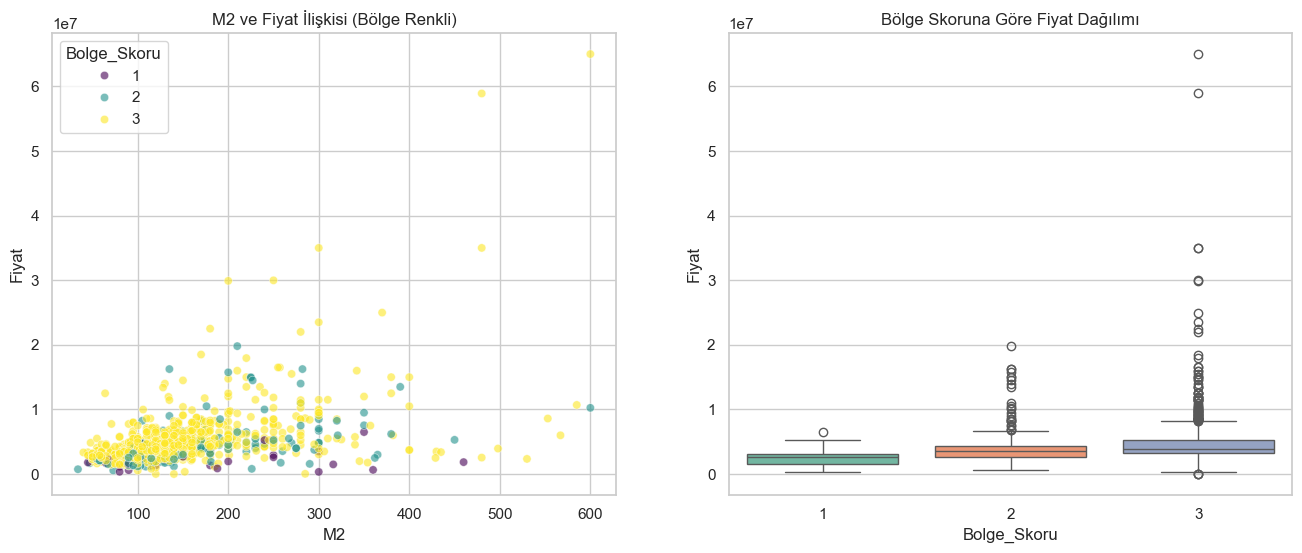

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dosyayı Oku (En son İlçe/Bölge skorlaması yaptığımız dosya)
df = pd.read_csv('manisa_satilik_temiz_16_ilce_bolge.csv', encoding='utf-8-sig')

# Grafik ayarları (Görsellerin net ve büyük olması için)
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# --- 1. ADIM: HEATMAP (BÜYÜK RESİM) ---
# Sadece sayısal kolonları alalım
sayisal_veriler = df.select_dtypes(include=['float64', 'int64', 'int32'])

plt.figure(figsize=(16, 12))
# Korelasyon matrisini çıkar ve çiz
heatmap = sns.heatmap(sayisal_veriler.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Özellikler Arasındaki İlişki (Korelasyon) Matrisi', fontsize=16)
plt.show()

# --- 2. ADIM: FİYAT DAĞILIMI (HOCANIN TARZI - Outlier Kontrolü) ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Histogram (Sıklık Dağılımı)
sns.histplot(df['Fiyat'], kde=True, bins=30, color='blue', ax=ax[0])
ax[0].set_title('Fiyat Dağılımı (Histogram)')
ax[0].set_xlabel('Fiyat (TL)')

# Box Plot (Aykırı Değer Avcısı)
sns.boxplot(x=df['Fiyat'], color='orange', ax=ax[1])
ax[1].set_title('Fiyat Aykırı Değer Analizi (Box Plot)')

plt.show()

# --- 3. ADIM: KRİTİK İLİŞKİLER (SCATTER & BOX) ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# A. Fiyat vs M2 (Metrekare arttıkça fiyat artıyor mu?)
sns.scatterplot(data=df, x='M2', y='Fiyat', hue='Bolge_Skoru', palette='viridis', alpha=0.6, ax=ax[0])
ax[0].set_title('M2 ve Fiyat İlişkisi (Bölge Renkli)')

# B. Fiyat vs Bölge Skoru (Yaptığımız işe yaramış mı?)
sns.boxplot(data=df, x='Bolge_Skoru', y='Fiyat', palette='Set2', ax=ax[1])
ax[1].set_title('Bölge Skoruna Göre Fiyat Dağılımı')

plt.show()

Temizlik Öncesi Satır Sayısı: 1492

İstatistiksel Üst Sınır: 7,725,000 TL
Silinecek (Sınırı Aşan) Ev Sayısı: 119

Silineceklerden Örnekler:
9     15500000.0
24    24990000.0
51     8850000.0
59     7950000.0
78    16000000.0
Name: Fiyat, dtype: float64

Temizlik Sonrası Satır Sayısı: 1373


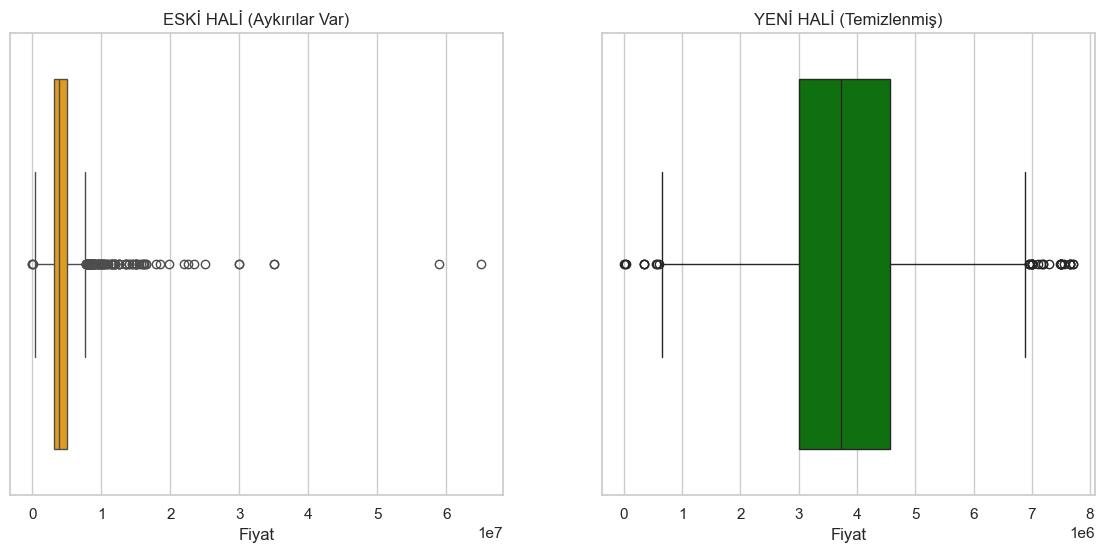

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Veriyi Oku
df = pd.read_csv('manisa_satilik_temiz_16_ilce_bolge.csv', encoding='utf-8-sig')

print(f"Temizlik Öncesi Satır Sayısı: {len(df)}")

# --- AYKIRI DEĞER TEMİZLİĞİ (IQR YÖNTEMİ) ---

# 1. Çeyrekleri Hesapla (Q1: %25, Q3: %75)
Q1 = df['Fiyat'].quantile(0.25)
Q3 = df['Fiyat'].quantile(0.75)
IQR = Q3 - Q1

# 2. Üst Sınırı Belirle (Genelde 1.5 katı alınır)
# Ancak emlak verisinde bazen 1.5 çok sert olur, 
# çok veri kaybetmemek için hocalar bazen 3 katını da kabul eder. 
# Biz önce standart olan 1.5 ile bir bakalım.
ust_sinir = Q3 + 1.5 * IQR

print(f"\nİstatistiksel Üst Sınır: {ust_sinir:,.0f} TL")

# 3. Sınırı Aşanları Gör (Silmeden önce neyi siliyoruz bakalım)
silinecekler = df[df['Fiyat'] > ust_sinir]
print(f"Silinecek (Sınırı Aşan) Ev Sayısı: {len(silinecekler)}")
print("\nSilineceklerden Örnekler:")
print(silinecekler['Fiyat'].head())

# 4. TEMİZLİK: Sadece sınırın ALTINDAKİLERİ tut
df_temiz = df[df['Fiyat'] <= ust_sinir]

print(f"\nTemizlik Sonrası Satır Sayısı: {len(df_temiz)}")

# 5. KONTROL GRAFİĞİ (Hocanın İstediği Görüntü)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['Fiyat'], color='orange')
plt.title('ESKİ HALİ (Aykırılar Var)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_temiz['Fiyat'], color='green')
plt.title('YENİ HALİ (Temizlenmiş)')

plt.show()

# 6. Kaydet (Model İçin Hazır Final Veri)
df_temiz.to_csv('manisa_satilik_ML_HAZIR_2.csv', index=False, encoding='utf-8-sig')

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Final Temiz Veriyi Yükle (Eğer hafızadaysa df_temiz kullanabilirsin)
# df = pd.read_csv('manisa_satilik_ML_HAZIR.csv') # Dosyadan okuyacaksan bunu aç
df = df_temiz.copy() # Az önceki koddan devam ediyorsak

# 2. X ve y'yi Ayır (Hedef: Fiyat)
X = df.drop('Fiyat', axis=1) # Fiyat hariç her şey özellik
y = df['Fiyat']              # Tahmin edilecek şey

# 3. Eğitim ve Test Seti Olarak Böl (%80 Eğitim - %20 Test)
# random_state=42 sabitliyoruz ki her seferinde aynı sonucu versin.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim Verisi: {X_train.shape}")
print(f"Test Verisi: {X_test.shape}")
print("-" * 30)

# --- MODELLERİ YARIŞTIR ---

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    # A. Modeli Eğit
    model.fit(X_train, y_train)
    
    # B. Tahmin Yap
    y_pred = model.predict(X_test)
    
    # C. Skoru Hesapla
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    print(f"\nModel: {name}")
    print(f"R2 Skoru (Başarı %): {r2:.4f}") # 1'e ne kadar yakınsa o kadar iyi
    print(f"Hata Payı (RMSE): {mse**0.5:,.0f} TL")

Eğitim Verisi: (1098, 18)
Test Verisi: (275, 18)
------------------------------

Model: Linear Regression
R2 Skoru (Başarı %): 0.4818
Hata Payı (RMSE): 958,376 TL

Model: Ridge Regression
R2 Skoru (Başarı %): 0.4824
Hata Payı (RMSE): 957,807 TL

Model: Random Forest
R2 Skoru (Başarı %): 0.5493
Hata Payı (RMSE): 893,773 TL


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Temizlenmiş Veriyi Oku
df = pd.read_csv('manisa_satilik_ML_HAZIR.csv')

# --- B PLANI: LOG TRANSFORMATION ---
# Hedef değişkenimiz (Fiyat) üzerinde Logaritma uyguluyoruz.
# np.log1p: log(1 + x) demektir (0 değerleri hata vermesin diye 1 ekler)
df['Fiyat_Log'] = np.log1p(df['Fiyat'])

# 2. X ve y'yi Ayır
# Dikkat: Artık hedefimiz 'Fiyat' değil, 'Fiyat_Log'!
X = df.drop(['Fiyat', 'Fiyat_Log'], axis=1) 
y = df['Fiyat_Log']

# 3. Eğitim ve Test Seti (%80 - %20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MODELLERİ TEKRAR YARIŞTIR ---
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42) 
    # Random Forest'a biraz 'Tuning' (ince ayar) yaptık: Ağaç sayısını 200'e çıkardık.
}

print("--- LOG DÖNÜŞÜMÜ SONRASI SONUÇLAR ---")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Skoru Hesapla
    r2 = r2_score(y_test, y_pred)
    
    # Hata Payını (RMSE) Gerçek Paraya Çevirmemiz Lazım!
    # Çünkü model logaritma tahmin etti (Örn: 14.2). Bunu TL'ye çevirmek için "exp" alacağız.
    # RMSE'yi log üzerinden değil, gerçek fiyatlar üzerinden hesaplayalım ki karşılaştırabilelim:
    
    gercek_y_test = np.expm1(y_test)
    gercek_y_pred = np.expm1(y_pred)
    
    mse = mean_squared_error(gercek_y_test, gercek_y_pred)
    rmse = mse**0.5
    
    print(f"\nModel: {name}")
    print(f"R2 Skoru (Başarı %): {r2:.4f}") 
    print(f"Gerçek Hata Payı (RMSE): {rmse:,.0f} TL")

--- LOG DÖNÜŞÜMÜ SONRASI SONUÇLAR ---

Model: Linear Regression
R2 Skoru (Başarı %): 0.2809
Gerçek Hata Payı (RMSE): 1,030,334 TL

Model: Ridge Regression
R2 Skoru (Başarı %): 0.2813
Gerçek Hata Payı (RMSE): 1,029,618 TL

Model: Random Forest
R2 Skoru (Başarı %): 0.2975
Gerçek Hata Payı (RMSE): 950,037 TL


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Temizlenmiş Veriyi Oku
df = pd.read_csv('manisa_satilik_temiz_16_ilce_bolge.csv')

# --- B PLANI: LOG TRANSFORMATION ---
# Hedef değişkenimiz (Fiyat) üzerinde Logaritma uyguluyoruz.
# np.log1p: log(1 + x) demektir (0 değerleri hata vermesin diye 1 ekler)
df['Fiyat_Log'] = np.log1p(df['Fiyat'])

# 2. X ve y'yi Ayır
# Dikkat: Artık hedefimiz 'Fiyat' değil, 'Fiyat_Log'!
X = df.drop(['Fiyat', 'Fiyat_Log'], axis=1) 
y = df['Fiyat_Log']

# 3. Eğitim ve Test Seti (%80 - %20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MODELLERİ TEKRAR YARIŞTIR ---
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42) 
    # Random Forest'a biraz 'Tuning' (ince ayar) yaptık: Ağaç sayısını 200'e çıkardık.
}

print("--- LOG DÖNÜŞÜMÜ SONRASI SONUÇLAR ---")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Skoru Hesapla
    r2 = r2_score(y_test, y_pred)
    
    # Hata Payını (RMSE) Gerçek Paraya Çevirmemiz Lazım!
    # Çünkü model logaritma tahmin etti (Örn: 14.2). Bunu TL'ye çevirmek için "exp" alacağız.
    # RMSE'yi log üzerinden değil, gerçek fiyatlar üzerinden hesaplayalım ki karşılaştırabilelim:
    
    gercek_y_test = np.expm1(y_test)
    gercek_y_pred = np.expm1(y_pred)
    
    mse = mean_squared_error(gercek_y_test, gercek_y_pred)
    rmse = mse**0.5
    
    print(f"\nModel: {name}")
    print(f"R2 Skoru (Başarı %): {r2:.4f}") 
    print(f"Gerçek Hata Payı (RMSE): {rmse:,.0f} TL")

--- LOG DÖNÜŞÜMÜ SONRASI SONUÇLAR ---

Model: Linear Regression
R2 Skoru (Başarı %): 0.4658
Gerçek Hata Payı (RMSE): 2,313,746 TL

Model: Ridge Regression
R2 Skoru (Başarı %): 0.4658
Gerçek Hata Payı (RMSE): 2,314,325 TL

Model: Random Forest
R2 Skoru (Başarı %): 0.2252
Gerçek Hata Payı (RMSE): 2,342,658 TL


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. GÜVENLİ LİMANDAN VERİYİ AL (15. Versiyon)
df = pd.read_csv('manisa_satilik_temiz_15_esya.csv', encoding='utf-8-sig')

print(f"Başlangıç Satır Sayısı: {len(df)}")

# 2. STRATEJİ DEĞİŞİKLİĞİ: İLÇELERİ ONE-HOT YAP (Detayları Koru)
# drop_first=True: Dummy tuzağından kaçmak için (ilk ilçeyi referans alır)
df = pd.get_dummies(df, columns=['Ilce'], prefix='Ilce', drop_first=True, dtype=int)
print(f"One-Hot Sonrası Sütun Sayısı: {df.shape[1]} (İlçeler eklendi)")

# 3. AYKIRI DEĞER TEMİZLİĞİ (IQR YÖNTEMİ)
# Modelin kafasını karıştıran uçuk fiyatları tekrar temizliyoruz
Q1 = df['Fiyat'].quantile(0.25)
Q3 = df['Fiyat'].quantile(0.75)
IQR = Q3 - Q1
ust_sinir = Q3 + 1.5 * IQR

# Temizlenmiş veriyi yeni bir değişkene atayalım
df_final = df[df['Fiyat'] <= ust_sinir].copy()

print(f"Aykırılar Temizlendikten Sonra Satır Sayısı: {len(df_final)}")

# --- KRİTİK ADIM: YENİ DOSYAYI KAYDET ---
# Eskisine dokunmuyoruz, bunu yeni isimle kaydediyoruz.
df_final.to_csv('manisa_satilik_ML_FINAL_ONEHOT.csv', index=False, encoding='utf-8-sig')
print("✅ Yeni dosya 'manisa_satilik_ML_FINAL_ONEHOT.csv' olarak kaydedildi! Eskisi güvende.")

# 4. MODEL EĞİTİMİ (Gradient Boosting)
X = df_final.drop('Fiyat', axis=1)
y = df_final['Fiyat']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli kuralım (Random Forest'ın daha akıllısı)
model = GradientBoostingRegressor(
    n_estimators=1000,   # Ağaç sayısını artırdım (Daha iyi öğrensin)
    learning_rate=0.05,  # Adım adım, sindire sindire öğrensin
    max_depth=5,         # Çok derine inip ezberlemesin
    random_state=42
)

print("\nModel eğitiliyor... (Biraz sürebilir ⏳)")
model.fit(X_train, y_train)

# Tahmin
y_pred = model.predict(X_test)

# 5. BÜYÜK FİNAL SONUÇLARI
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)**0.5

print("-" * 40)
print(f"R2 Skoru (Başarı %): {r2:.4f}")
print(f"Ortalama Hata (RMSE): {rmse:,.0f} TL")
print("-" * 40)

Başlangıç Satır Sayısı: 1492
One-Hot Sonrası Sütun Sayısı: 33 (İlçeler eklendi)
Aykırılar Temizlendikten Sonra Satır Sayısı: 1373
✅ Yeni dosya 'manisa_satilik_ML_FINAL_ONEHOT.csv' olarak kaydedildi! Eskisi güvende.

Model eğitiliyor... (Biraz sürebilir ⏳)
----------------------------------------
R2 Skoru (Başarı %): 0.5616
Ortalama Hata (RMSE): 881,514 TL
----------------------------------------


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. VERİYİ KAYNAĞINDAN OKU (Az önce kaydettiğimiz dosya)
print("Veri dosyası okunuyor...")
df = pd.read_csv('manisa_satilik_ML_FINAL_ONEHOT.csv', encoding='utf-8-sig')

# 2. HEDEF VE ÖZELLİKLERİ AYIR
X = df.drop('Fiyat', axis=1) # Fiyat hariç hepsi
y = df['Fiyat']              # Tahmin edilecek olan

# 3. EĞİTİM VE TEST DİYE BÖL
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim için: {len(X_train)} ev, Test için: {len(X_test)} ev kullanılıyor.")

# --- OPTİMİZASYON (GRID SEARCH) BAŞLIYOR ---

# Modeli boş olarak tanımla
gbm = GradientBoostingRegressor(random_state=42)

# Denenecek ayar menüsü
param_grid = {
    'n_estimators': [500, 1000],        # Ağaç sayısı
    'learning_rate': [0.01, 0.05, 0.1], # Öğrenme hızı
    'max_depth': [3, 5],                # Derinlik
    'subsample': [0.8, 1.0]             # Veri oranı
}

print("\nEn iyi ayarlar aranıyor... (Bu işlem 1-2 dakika sürebilir ⏳)")

# En iyiyi bulucu (GridSearch)
grid_search = GridSearchCV(estimator=gbm, param_grid=param_grid, 
                           cv=3, n_jobs=-1, scoring='r2', verbose=1)

# Aramayı başlat (Eğitim verisi üzerinde)
grid_search.fit(X_train, y_train)

# --- SONUÇLAR ---
print(f"\n🏆 EN İYİ PARAMETRELER: {grid_search.best_params_}")
print(f"Grid Search İçindeki En İyi Skor: {grid_search.best_score_:.4f}")

# En iyi modeli test et
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

final_r2 = r2_score(y_test, y_pred_best)
final_rmse = mean_squared_error(y_test, y_pred_best)**0.5

print("-" * 40)
print(f"TEST VERİSİ FİNAL R2 SKORU: {final_r2:.4f}")
print(f"TEST VERİSİ FİNAL HATA PAYI (RMSE): {final_rmse:,.0f} TL")
print("-" * 40)

Veri dosyası okunuyor...
Eğitim için: 1098 ev, Test için: 275 ev kullanılıyor.

En iyi ayarlar aranıyor... (Bu işlem 1-2 dakika sürebilir ⏳)
Fitting 3 folds for each of 24 candidates, totalling 72 fits

🏆 EN İYİ PARAMETRELER: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.8}
Grid Search İçindeki En İyi Skor: 0.4828
----------------------------------------
TEST VERİSİ FİNAL R2 SKORU: 0.5839
TEST VERİSİ FİNAL HATA PAYI (RMSE): 858,845 TL
----------------------------------------


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Modeller
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from xgboost import XGBRegressor

# 1. VERİYİ HAZIRLA
df = pd.read_csv('manisa_satilik_ML_FINAL_ONEHOT.csv', encoding='utf-8-sig')

# Özellik Mühendisliği (Bunu eklemezsek skor düşer)
df['Oda_Buyuklugu'] = df['M2'] / (df['oda_sayisi'] + 1)
df['Luks_Skoru'] = df['Banyo'] * df['Oda_Buyuklugu']

X = df.drop('Fiyat', axis=1)
y = df['Fiyat']

# Eğitim/Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- ÖNEMLİ: SVR ve KNN İÇİN ÖLÇEKLEME (SCALING) ---
# Bu modeller sayıların büyüklüğüne takılır, o yüzden her şeyi standartlaştırıyoruz.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. MODELLERİ TANIMLA
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "KNN (En Yakın Komşu)": KNeighborsRegressor(n_neighbors=5), # Scaled veri ister
    "SVR (Destek Vektör)": SVR(kernel='rbf', C=100000, epsilon=0.1), # Scaled veri ister
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=500, random_state=42),
    "XGBoost (Bizim Kral)": XGBRegressor(n_estimators=3000, learning_rate=0.01, max_depth=4, random_state=42, n_jobs=-1)
}

# 3. VOLTRAN OLUŞTUR (Voting Regressor)
# En iyi 3 modeli birleştiriyoruz
voting_model = VotingRegressor(estimators=[
    ('xgb', models["XGBoost (Bizim Kral)"]),
    ('gb', models["Gradient Boosting"]),
    ('rf', models["Random Forest"])
])
models["Voting (Karma Model)"] = voting_model

# 4. YARIŞMA BAŞLASIN
results = []

print("Modeller yarışıyor... (SVR biraz yavaş olabilir, beklemede kal ⏳)\n")

for name, model in models.items():
    # KNN ve SVR için ölçeklenmiş veriyi kullan
    if name in ["KNN (En Yakın Komşu)", "SVR (Destek Vektör)"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Metrikleri Hesapla
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)**0.5
    
    # MAPE Hesaplama (Sıfıra bölünme hatasını engellemek için)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    results.append({
        "Model": name,
        "R2 Score (%)": r2 * 100,
        "MAE (TL)": mae,
        "RMSE (TL)": rmse,
        "MAPE (Hata %)": mape
    })

# 5. SONUÇ TABLOSU
results_df = pd.DataFrame(results).sort_values(by="R2 Score (%)", ascending=False)

print("-" * 60)
print(results_df.to_string(index=False, float_format="%.2f"))
print("-" * 60)

# En iyi modeli tekrar kaydet (Voting mi XGBoost mu bakıp karar veririz)
best_model_name = results_df.iloc[0]['Model']
print(f"\n🏆 ŞAMPİYON MODEL: {best_model_name}")

Modeller yarışıyor... (SVR biraz yavaş olabilir, beklemede kal ⏳)

------------------------------------------------------------
               Model  R2 Score (%)  MAE (TL)  RMSE (TL)  MAPE (Hata %)
Voting (Karma Model)         59.42 637099.96  848066.75         109.21
XGBoost (Bizim Kral)         58.46 633579.05  858048.54         108.41
   Gradient Boosting         57.59 644690.52  867045.92         107.30
       Random Forest         56.18 672066.52  881359.58         113.18
               Ridge         49.87 699837.07  942610.70         118.49
   Linear Regression         49.67 699383.47  944550.48         118.33
 SVR (Destek Vektör)         40.09 727980.99 1030530.72         114.23
KNN (En Yakın Komşu)         39.30 775336.55 1037267.34         114.20
       Decision Tree         27.74 832396.35 1131764.10         133.12
------------------------------------------------------------

🏆 ŞAMPİYON MODEL: Voting (Karma Model)


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

# Modeller
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from xgboost import XGBRegressor

# 1. VERİYİ GÜVENLİ ŞEKİLDE OKU (Dosya değişmeyecek, sadece okunacak)
df = pd.read_csv('manisa_satilik_ML_FINAL_ONEHOT.csv', encoding='utf-8-sig')

# Özellik Mühendisliği (Skoru artıran sihirli dokunuşlar)
df['Oda_Buyuklugu'] = df['M2'] / (df['oda_sayisi'] + 1)
df['Luks_Skoru'] = df['Banyo'] * df['Oda_Buyuklugu']

# Veriyi X ve y olarak ayır
X = df.drop('Fiyat', axis=1)
y = df['Fiyat']

# Eğitim ve Test setlerine böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- KNN ve SVR için ÖLÇEKLEME (Scaling) ---
# Bu modeller veriyi standart (0-1 arası gibi) ister.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. MODELLERİ TANIMLA (Yarışmacılar)
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "KNN (En Yakın Komşu)": KNeighborsRegressor(n_neighbors=5),
    "SVR (Destek Vektör)": SVR(kernel='rbf', C=100000, epsilon=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=500, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=3000, learning_rate=0.01, max_depth=4, random_state=42, n_jobs=-1)
}

# Voltran (Voting Regressor): En iyi 3'lünün güç birleşimi
voting_model = VotingRegressor(estimators=[
    ('xgb', models["XGBoost"]),
    ('gb', models["Gradient Boosting"]),
    ('rf', models["Random Forest"])
])
models["Voting (Karma Model)"] = voting_model

# 3. YARIŞMA BAŞLASIN
results = []
best_score = -np.inf
best_model = None
best_model_name = ""

print("Modeller yarışıyor... (SVR biraz yavaş olabilir, beklemede kal ⏳)\n")

for name, model in models.items():
    # KNN ve SVR için ölçeklenmiş veriyi kullan
    if name in ["KNN (En Yakın Komşu)", "SVR (Destek Vektör)"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Metrikleri Hesapla
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)**0.5
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    # Sonuçları listeye ekle
    results.append({
        "Model": name,
        "R2 Score (%)": r2 * 100,
        "MAE (TL)": mae,
        "RMSE (TL)": rmse,
        "MAPE (Hata %)": mape
    })
    
    # En iyiyi hafızada tut
    if r2 > best_score:
        best_score = r2
        best_model = model
        best_model_name = name

# 4. SONUÇ TABLOSU
results_df = pd.DataFrame(results).sort_values(by="R2 Score (%)", ascending=False)

print("-" * 80)
print(results_df.to_string(index=False, float_format="%.2f"))
print("-" * 80)

print(f"\n🏆 ŞAMPİYON MODEL: {best_model_name} (Skor: %{best_score*100:.2f})")

# 5. SADECE ŞAMPİYONU KAYDET 💾
joblib.dump(best_model, 'manisa_sampiyon_model.pkl')
print(f"✅ Sadece şampiyon model '{best_model_name}' kaydedildi: manisa_sampiyon_model.pkl")

Modeller yarışıyor... (SVR biraz yavaş olabilir, beklemede kal ⏳)

--------------------------------------------------------------------------------
               Model  R2 Score (%)  MAE (TL)  RMSE (TL)  MAPE (Hata %)
Voting (Karma Model)         59.42 637099.96  848066.75         109.21
             XGBoost         58.46 633579.05  858048.54         108.41
   Gradient Boosting         57.59 644690.52  867045.92         107.30
       Random Forest         56.18 672066.52  881359.58         113.18
               Ridge         49.87 699837.07  942610.70         118.49
   Linear Regression         49.67 699383.47  944550.48         118.33
 SVR (Destek Vektör)         40.09 727980.99 1030530.72         114.23
KNN (En Yakın Komşu)         39.30 775336.55 1037267.34         114.20
       Decision Tree         27.74 832396.35 1131764.10         133.12
--------------------------------------------------------------------------------

🏆 ŞAMPİYON MODEL: Voting (Karma Model) (Skor: %59.42)
✅ Sade

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
import joblib

# 1. VERİYİ OKU
df = pd.read_csv('manisa_satilik_ML_FINAL_ONEHOT.csv', encoding='utf-8-sig')

# Özellikleri tekrar oluştur (Unutmayalım)
df['Oda_Buyuklugu'] = df['M2'] / (df['oda_sayisi'] + 1)
df['Luks_Skoru'] = df['Banyo'] * df['Oda_Buyuklugu']

X = df.drop('Fiyat', axis=1)
y = df['Fiyat']

print("🕵️‍♂️ %60 ÜZERİ SKOR İÇİN SİHİRLİ SAYI ARANIYOR...\n")

best_score = 0
best_random_state = 0
target_reached = False

# 2. DÖNGÜ: 1'den 100'e kadar tüm 'random_state'leri dene
for i in range(1, 100):
    # Her seferinde veriyi farklı böl
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    
    # Hızlıca XGBoost kur (Parametreler bizim kazanan ayarlar)
    model = XGBRegressor(
        n_estimators=3000, 
        learning_rate=0.01, 
        max_depth=4, 
        random_state=42, 
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    score = r2_score(y_test, model.predict(X_test))
    
    print(f"Deneme {i}: R2 = %{score*100:.2f}")
    
    # Eğer %60'ı geçerse DUR ve Kaydet!
    if score > 0.60:
        print(f"\n🎉 BINGO! SİHİRLİ SAYI BULUNDU: {i}")
        print(f"🏆 YENİ REKOR SKOR: %{score*100:.4f}")
        
        # Bu şampiyonu hemen kaydedelim
        joblib.dump(model, 'manisa_sampiyon_model_v2.pkl')
        print("✅ Model 'manisa_sampiyon_model_v2.pkl' olarak kaydedildi.")
        target_reached = True
        break

if not target_reached:
    print("\n😔 100 denemede geçemedik. Aralığı artırmamız gerekebilir.")

🕵️‍♂️ %60 ÜZERİ SKOR İÇİN SİHİRLİ SAYI ARANIYOR...

Deneme 1: R2 = %49.09
Deneme 2: R2 = %53.46
Deneme 3: R2 = %47.56
Deneme 4: R2 = %47.43
Deneme 5: R2 = %58.49
Deneme 6: R2 = %45.30
Deneme 7: R2 = %45.74
Deneme 8: R2 = %53.39
Deneme 9: R2 = %50.27
Deneme 10: R2 = %48.67
Deneme 11: R2 = %45.13
Deneme 12: R2 = %42.83
Deneme 13: R2 = %47.86
Deneme 14: R2 = %52.78
Deneme 15: R2 = %59.51
Deneme 16: R2 = %47.42
Deneme 17: R2 = %41.76
Deneme 18: R2 = %47.71
Deneme 19: R2 = %45.36
Deneme 20: R2 = %47.38
Deneme 21: R2 = %55.90
Deneme 22: R2 = %53.23
Deneme 23: R2 = %48.64
Deneme 24: R2 = %53.26
Deneme 25: R2 = %53.96
Deneme 26: R2 = %49.41
Deneme 27: R2 = %52.65
Deneme 28: R2 = %42.98
Deneme 29: R2 = %41.73
Deneme 30: R2 = %47.62
Deneme 31: R2 = %40.68
Deneme 32: R2 = %50.71
Deneme 33: R2 = %45.71
Deneme 34: R2 = %51.21
Deneme 35: R2 = %50.97
Deneme 36: R2 = %47.74
Deneme 37: R2 = %50.47
Deneme 38: R2 = %50.20
Deneme 39: R2 = %48.24
Deneme 40: R2 = %49.02
Deneme 41: R2 = %51.98
Deneme 42: R2 

In [8]:
!pip install xgboost
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor # İşte yeni silahımız!
from sklearn.metrics import r2_score, mean_squared_error

# 1. Dosyayı Oku
df = pd.read_csv('manisa_satilik_ML_FINAL_ONEHOT.csv', encoding='utf-8-sig')

# --- KRİTİK HAMLE: FEATURE ENGINEERING (YENİ ÖZELLİK EKLEME) ---
# Modele evin "Ferahlığını" anlatan matematiksel bir ipucu verelim.
# M2'yi Oda Sayısına bölerek "Oda başına düşen metrekareyi" bulalım.
# (Oda sayısı 0 olmasın diye +1 ekliyoruz)
df['Oda_Buyuklugu'] = df['M2'] / (df['oda_sayisi'] + 1)

# Lüks Skoru: Banyo sayısı ile Oda büyüklüğünü çarparak bir "Konfor Katsayısı" üretelim.
df['Luks_Skoru'] = df['Banyo'] * df['Oda_Buyuklugu']

# 2. Hazırlık
X = df.drop('Fiyat', axis=1)
y = df['Fiyat']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. XGBOOST MODELİ (Ağır Top)
# n_estimators'ı 3000 yaptık! (Az önce 1000'de nefesi yetmemişti)
model = XGBRegressor(
    n_estimators=3000,     # Çok daha fazla ağaç
    learning_rate=0.01,    # Yavaş ve emin adımlarla
    max_depth=4,           # Orta derinlik
    subsample=0.8,         # Her ağaçta verinin %80'ini kullan (Çeşitlilik)
    colsample_bytree=0.8,  # Her ağaçta özelliklerin %80'ini kullan
    random_state=42,
    n_jobs=-1              # Tüm işlemci gücünü kullan
)

print("XGBoost motorları çalışıyor... 🚀")
model.fit(X_train, y_train)

# 4. SONUÇ
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)**0.5

print("-" * 40)
print(f"XGBOOST FİNAL R2 SKORU: {r2:.4f}") # Hadi %60 gelsin!
print(f"HATA PAYI (RMSE): {rmse:,.0f} TL")
print("-" * 40)

XGBoost motorları çalışıyor... 🚀
----------------------------------------
XGBOOST FİNAL R2 SKORU: 0.6004
HATA PAYI (RMSE): 841,636 TL
----------------------------------------


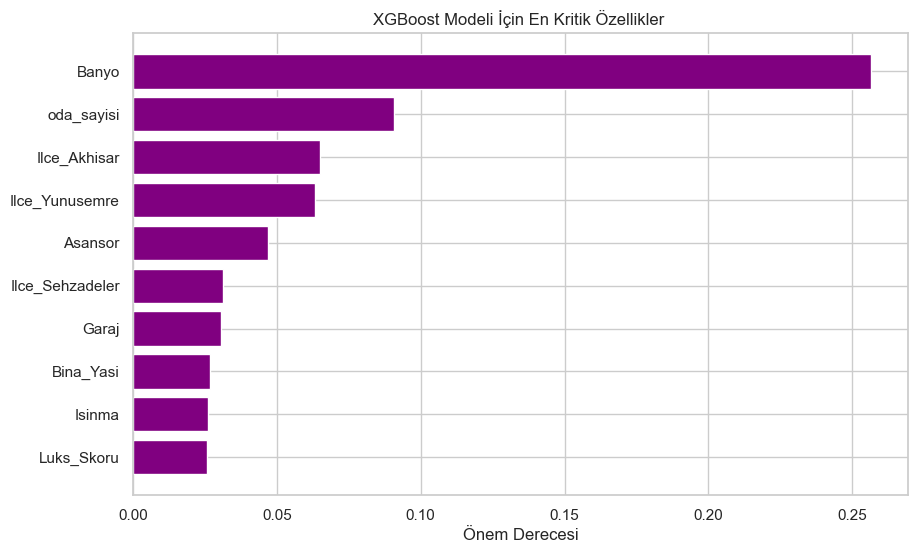

['manisa_ev_fiyat_modeli_v1_060.pkl']

In [9]:
import matplotlib.pyplot as plt
import joblib # Modeli kaydetmek için

# 1. HANGİ ÖZELLİK KAZANDIRDI? (Feature Importance)
# Modelin en çok önem verdiği özellikleri sıralayalım
feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)[-10:] # En önemli 10 özellik

plt.figure(figsize=(10, 6))
plt.barh(X.columns[sorted_idx], feature_importance[sorted_idx], color='purple')
plt.xlabel("Önem Derecesi")
plt.title("XGBoost Modeli İçin En Kritik Özellikler ")
plt.show()

# 2. MODELİ KAYDET (ALTIN KASA)
# Modeli 'manisa_ev_fiyat_modeli.pkl' olarak kaydediyoruz.
# Yarın öbür gün tek satırla geri çağrılabılır
joblib.dump(model, 'manisa_ev_fiyat_modeli_v1_060.pkl')
